In [1]:
# @title 1. Instalasi Pustaka dan Impor Modul
# Instalasi pustaka yang diperlukan dari Hugging Face dan lainnya
!pip install transformers[torch] datasets accelerate scikit-learn pandas wordcloud matplotlib seaborn -q

import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import drive

# Impor dari sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Impor dari Hugging Face
from datasets import Dataset
from transformers import AutoTokenizer, BertTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer

# Untuk hasil yang bisa direproduksi
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Setup selesai. Semua pustaka berhasil diinstal dan diimpor.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.5 MB/s eta 0:00:00
Setup selesai. Semua pustaka berhasil diinstal dan diimpor.


In [2]:
# @title 2. Hubungkan ke Google Drive dan Muat Dataset
# Hubungkan ke Google Drive
drive.mount('/content/drive')

# Definisikan path file Anda
file_path = '/content/drive/MyDrive/Modul Penelitian 1/results/high_confidence_enhanced_tweets.csv'

# Muat dataset
try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path '{file_path}'. Pastikan path sudah benar.")
    # Hentikan eksekusi jika file tidak ada
    assert False

# --- Persiapan Data ---
# 1. Pilih kolom yang relevan
df = df[['clean_text', 'predicted_label']]
df.rename(columns={'clean_text': 'text', 'predicted_label': 'sentiment'}, inplace=True)

# 2. Hapus baris dengan data teks yang kosong jika ada
df.dropna(subset=['text'], inplace=True)
df = df[df['text'].str.strip() != '']

# 3. Buat pemetaan label ke angka (integer) dan sebaliknya
labels = df['sentiment'].unique().tolist()
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

# Tambahkan kolom 'label' numerik ke dataframe
df['label'] = df['sentiment'].map(label2id)

print("\nDistribusi Label:")
print(df['sentiment'].value_counts())

print("\nContoh Data setelah persiapan:")
print(df.head())

print("\nPemetaan Label:")
print("id2label:", id2label)
print("label2id:", label2id)

Mounted at /content/drive
Dataset berhasil dimuat.

Distribusi Label:
sentiment
negative    5326
positive    3706
neutral      339
Name: count, dtype: int64

Contoh Data setelah persiapan:
                                                text sentiment  label
0  aku sih enggak sepenuhnya yakin bahwa efisiens...  negative      0
1   ternyata efisiensi anggaran cuma buat umbiumbian  negative      0
2  sikap periset soal efisiensi anggaran kembalik...  positive      1
3  efisiensi anggaran hanya membuat dana is berku...  negative      0
4  pak katanya perlu efisiensi anggaran bukankah ...  negative      0

Pemetaan Label:
id2label: {0: 'negative', 1: 'positive', 2: 'neutral'}
label2id: {'negative': 0, 'positive': 1, 'neutral': 2}


Membuat word cloud untuk setiap sentimen...


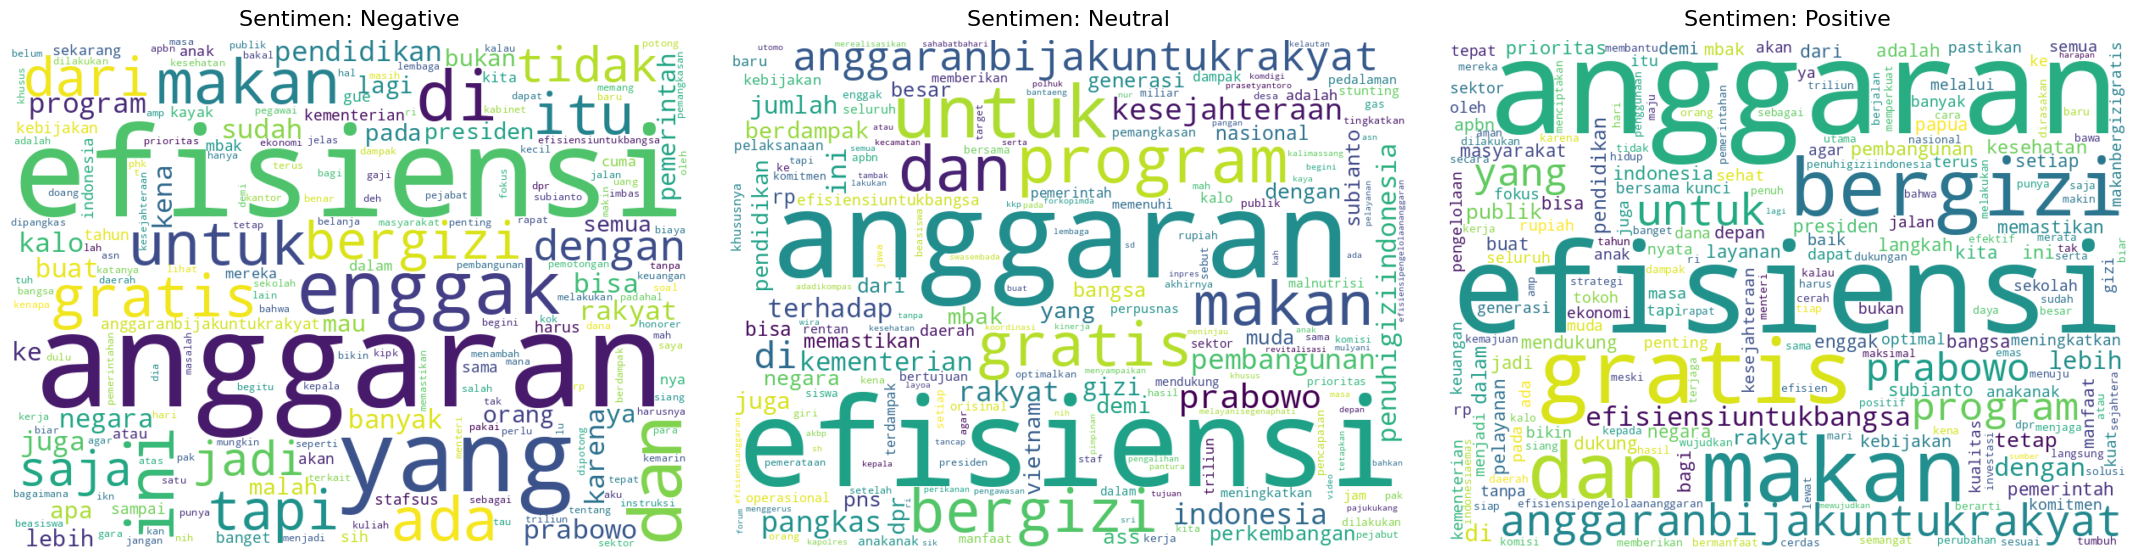

In [4]:
# @title 3. (Diperbarui) Membuat Word Cloud per Sentimen
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Mendapatkan daftar sentimen unik dari data Anda
sentiments = df['sentiment'].unique()

# Membuat layout subplot untuk menampilkan beberapa word cloud sekaligus
# Misalnya, jika ada 3 sentimen, kita akan buat 1 baris dengan 3 kolom
fig, axes = plt.subplots(1, len(sentiments), figsize=(22, 7))

# Jika hanya ada satu sentimen, ubah 'axes' menjadi list agar bisa di-loop
if len(sentiments) == 1:
    axes = [axes]

print("Membuat word cloud untuk setiap sentimen...")

# Loop melalui setiap sentimen untuk membuat word cloud masing-masing
for i, sentiment in enumerate(sorted(sentiments)): # sorted() agar urutannya konsisten

    # Saring dataframe untuk mendapatkan teks hanya untuk sentimen saat ini
    sentiment_text = " ".join(text for text in df[df['sentiment'] == sentiment].text)

    # Cek jika ada teks untuk diproses
    if not sentiment_text:
        print(f"Tidak ada teks untuk sentimen '{sentiment}', word cloud dilewati.")
        axes[i].set_title(f'Sentimen: {sentiment.capitalize()}\n(Tidak ada data)', fontsize=14)
        axes[i].axis("off")
        continue

    # Buat objek WordCloud
    wordcloud = WordCloud(width=800,
                          height=600,
                          background_color="white",
                          colormap='viridis', # Anda bisa ganti palet warna di sini
                          collocations=False, # Nonaktifkan bigram
                          min_font_size=10).generate(sentiment_text)

    # Tampilkan gambar pada subplot yang sesuai
    ax = axes[i]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Sentimen: {sentiment.capitalize()}', fontsize=16, pad=10)
    ax.axis("off")

# Atur layout agar rapi dan tidak tumpang tindih
plt.tight_layout(pad=3.0)
plt.show()

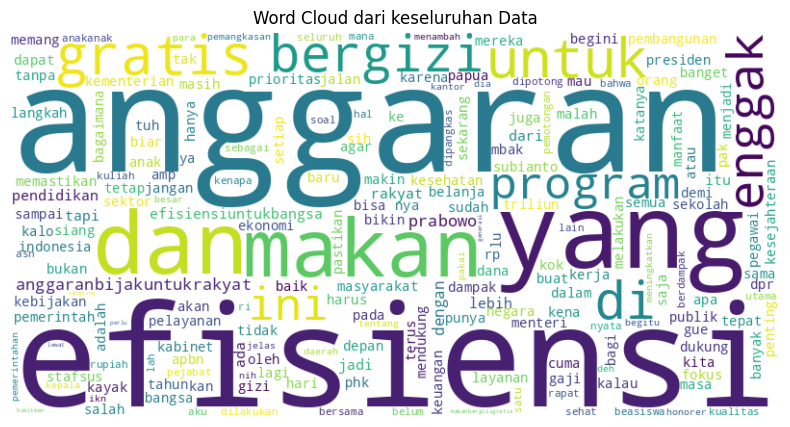

In [5]:
# @title 3. Membuat Word Cloud dari Teks
# Gabungkan semua teks menjadi satu string besar
all_text = " ".join(text for text in df.text)

# Buat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white", collocations=False).generate(all_text)

# Tampilkan gambar
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud dari keseluruhan Data")
plt.show()

In [6]:
# @title 9. Membuat Tabel Frekuensi Kata
from collections import Counter
import pandas as pd

# --- Fungsi untuk menghasilkan tabel frekuensi ---
def generate_frequency_table(text_series, top_n=20):
    """
    Menerima pandas Series berisi teks, lalu mengembalikan DataFrame
    frekuensi kata yang sudah diurutkan.
    """
    # Gabungkan semua baris teks menjadi satu string, lalu pisahkan menjadi kata-kata
    all_words = " ".join(text for text in text_series).split()

    # Hitung frekuensi setiap kata
    word_counts = Counter(all_words)

    # Ubah hasil Counter menjadi DataFrame
    freq_df = pd.DataFrame(word_counts.items(), columns=['Kata', 'Frekuensi'])

    # Urutkan DataFrame berdasarkan frekuensi dari yang tertinggi
    freq_df_sorted = freq_df.sort_values(by='Frekuensi', ascending=False)

    # Kembalikan N kata teratas
    return freq_df_sorted.head(top_n)

# --- 1. Frekuensi Kata dari Keseluruhan Data ---
print("="*40)
print("Tabel Frekuensi Kata (Keseluruhan Data)")
print("="*40)
overall_freq_table = generate_frequency_table(df['text'], top_n=25)
print(overall_freq_table.to_string(index=False))
print("\n")


# --- 2. Frekuensi Kata per Kategori Sentimen ---
sentiments = sorted(df['sentiment'].unique())

for sentiment in sentiments:
    print("="*40)
    print(f"Tabel Frekuensi Kata (Sentimen: {sentiment.capitalize()})")
    print("="*40)

    # Saring data untuk sentimen saat ini
    sentiment_text_series = df[df['sentiment'] == sentiment]['text']

    # Buat tabel frekuensi untuk sentimen ini
    sentiment_freq_table = generate_frequency_table(sentiment_text_series, top_n=25)

    # Tampilkan tabel tanpa index
    print(sentiment_freq_table.to_string(index=False))
    print("\n")

Tabel Frekuensi Kata (Keseluruhan Data)
                    Kata  Frekuensi
                anggaran       8636
               efisiensi       8320
                    yang       4005
                     dan       2597
                   makan       2215
                  gratis       2115
                   untuk       2054
                      di       1940
                 bergizi       1904
                  enggak       1761
                 program       1488
                     ini       1486
anggaranbijakuntukrakyat       1407
                 prabowo       1364
                  dengan       1231
                     ada       1089
                    dari       1028
                     itu       1015
    efisiensiuntukbangsa        967
                  rakyat        959
                    tapi        955
                   lebih        945
              pendidikan        935
                    jadi        882
                    bisa        748


Tabel Frekuensi Kata (

In [8]:
# @title 4. Pembagian Data (Train-Validation-Test Split)
# Memisahkan set Uji (Test set) terlebih dahulu (20% dari total data)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label'] # Stratified split
)

# Memisahkan sisa data menjadi set Latih dan Validasi
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15, # 15% dari sisa 80% data
    random_state=42,
    stratify=train_val_df['label'] # Stratified split
)

print(f"Ukuran Data Latih: {len(train_df)}")
print(f"Ukuran Data Validasi: {len(val_df)}")
print(f"Ukuran Data Uji: {len(test_df)}")

# Verifikasi distribusi di setiap set
print("\nDistribusi Label di Set Latih:")
print(train_df['sentiment'].value_counts(normalize=True))
print("\nDistribusi Label di Set Validasi:")
print(val_df['sentiment'].value_counts(normalize=True))
print("\nDistribusi Label di Set Uji:")
print(test_df['sentiment'].value_counts(normalize=True))

# Konversi ke format Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

Ukuran Data Latih: 6371
Ukuran Data Validasi: 1125
Ukuran Data Uji: 1875

Distribusi Label di Set Latih:
sentiment
negative    0.568357
positive    0.395542
neutral     0.036101
Name: proportion, dtype: float64

Distribusi Label di Set Validasi:
sentiment
negative    0.568000
positive    0.395556
neutral     0.036444
Name: proportion, dtype: float64

Distribusi Label di Set Uji:
sentiment
negative    0.568533
positive    0.395200
neutral     0.036267
Name: proportion, dtype: float64


In [9]:
# @title 5. Menghitung Bobot Kelas (Class Weighting)
# Hitung bobot berdasarkan data latih
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Konversi ke PyTorch Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# Pindahkan ke GPU jika tersedia
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights_tensor = class_weights_tensor.to(device)

print(f"Bobot Kelas (Class Weights): {class_weights}")
print(f"Kelas yang sesuai: {np.unique(train_df['label'])}")
print(f"Menggunakan device: {device}")

Bobot Kelas (Class Weights): [0.58648624 0.84272487 9.23333333]
Kelas yang sesuai: [0 1 2]
Menggunakan device: cuda


In [ ]:
# @title 6. (Perbaikan Final untuk Konsistensi)
# --- Definisikan Model dan Hyperparameter untuk Diuji ---
model_checkpoints = [
    "indobenchmark/indobert-base-p1",
    "indolem/indobertweet-base-uncased",
    "bert-base-multilingual-uncased"
]
learning_rates = [5e-5, 3e-5, 2e-5]
batch_size = 16
num_epochs = 4

# --- Siapkan Fungsi dan Kelas Bantu ---
def compute_metrics(pred):
    """Fungsi untuk menghitung metrik evaluasi."""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

class WeightedLossTrainer(Trainer):
    """Custom Trainer untuk menggunakan class weights."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# --- Loop Pelatihan ---
all_run_results = []
best_model_so_far = {
    'trainer': None,
    'f1_score': -1.0,
    'details': {}
}

for model_name in model_checkpoints:
    print(f"\n{'='*25}\n   MEMPROSES MODEL: {model_name}\n{'='*25}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)

    for lr in learning_rates:
        print(f"\n--- Melatih dengan Learning Rate: {lr} ---")

        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=len(labels),
            id2label=id2label,
            label2id=label2id
        ).to(device)

        training_args = TrainingArguments(
            output_dir=f'./results/{model_name.replace("/", "_")}_{lr}',
            num_train_epochs=num_epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            learning_rate=lr,
            weight_decay=0.01,
            logging_dir='./logs',
            report_to="none"
        )

        trainer = WeightedLossTrainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            compute_metrics=compute_metrics,
        )

        trainer.train()

        print("\nMelakukan evaluasi pada data validasi...")
        eval_result = trainer.evaluate()

        # **PERBAIKAN KUNCI DI SINI**
        # Gabungkan info model dan hasil evaluasi secara langsung
        run_info = {'model': model_name, 'learning_rate': lr}
        run_info.update(eval_result) # Ini akan menambahkan kunci seperti 'eval_f1', 'eval_accuracy', dll.
        all_run_results.append(run_info)

        # Gunakan 'eval_f1' untuk perbandingan
        current_f1 = eval_result['eval_f1']
        if current_f1 > best_model_so_far['f1_score']:
            print(f">>> Ditemukan F1-score yang lebih baik: {current_f1:.4f}. Menyimpan model ini.")
            best_model_so_far['f1_score'] = current_f1
            best_model_so_far['trainer'] = trainer
            best_model_so_far['details'] = run_info

        del model
        torch.cuda.empty_cache()

print("\nEksperimen Selesai!")

# Definisikan 'best_run' untuk digunakan di bagian selanjutnya
best_run = best_model_so_far['details']
best_run['trainer'] = best_model_so_far['trainer']


   MEMPROSES MODEL: indobenchmark/indobert-base-p1


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



--- Melatih dengan Learning Rate: 3e-05 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Step,Training Loss
500,0.702100
1000,0.398600


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
# @title 7. (Diperbarui) Tampilkan Hasil Eksperimen dan Pilih Model Terbaik

# Pastikan list 'all_run_results' ada dan tidak kosong
if 'all_run_results' in locals() and all_run_results:
    results_df = pd.DataFrame(all_run_results)

    # **PERBAIKAN:** Menggunakan 'eval_f1' sebagai kunci untuk sorting
    results_df_sorted = results_df.sort_values(by='eval_f1', ascending=False)

    print("--- Hasil Eksperimen Hyperparameter Tuning ---")

    # Menampilkan kolom yang relevan saja agar tidak terlalu lebar
    display_cols = ['model', 'learning_rate', 'eval_f1', 'eval_accuracy', 'eval_precision', 'eval_recall', 'epoch']
    print(results_df_sorted[display_cols].to_string(index=False))

    # Ambil model terbaik berdasarkan F1-score tertinggi
    best_model_info = results_df_sorted.iloc[0]
    print("\n--- Model Terbaik Dipilih ---")
    print(f"Model: {best_model_info['model']}")
    print(f"Learning Rate: {best_model_info['learning_rate']}")
    # **PERBAIKAN:** Menggunakan 'eval_f1' untuk menampilkan skor
    print(f"Skor F1 Validasi: {best_model_info['eval_f1']:.4f}")
else:
    print("Error: List hasil ('all_run_results') tidak ditemukan atau kosong. Jalankan kembali Bagian 6.")

Error: List hasil ('all_run_results') tidak ditemukan atau kosong. Jalankan kembali Bagian 6.


In [ ]:
# @title 7.5. Grafik Hasil Hyperparameter Tuning

# Pastikan results_df ada dari Bagian 7
if 'results_df' in locals() and not results_df.empty:

    # Membuat nama model lebih pendek agar rapi di legenda grafik
    results_df['model_short_name'] = results_df['model'].apply(lambda x: x.split('/')[-1])

    plt.figure(figsize=(12, 8))

    # Membuat line plot menggunakan seaborn untuk visualisasi yang lebih menarik
    sns.lineplot(
        data=results_df,
        x='learning_rate',
        y='eval_f1',
        hue='model_short_name', # Gunakan nama pendek untuk legenda
        style='model_short_name', # Gunakan style garis berbeda untuk setiap model
        markers=True, # Tambahkan penanda titik untuk setiap data point
        markersize=10,
        linewidth=2.5
    )

    # Mengatur format sumbu-x agar learning rate tampil dengan notasi ilmiah
    plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.xticks(learning_rates) # Memastikan semua learning rate yang diuji muncul di sumbu-x

    # Menambahkan judul dan label
    plt.title('Perbandingan Kinerja Model Berdasarkan Learning Rate', fontsize=16, pad=20)
    plt.xlabel('Learning Rate', fontsize=12)
    plt.ylabel('Skor F1 pada Data Validasi', fontsize=12)
    plt.legend(title='Model', fontsize=10)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("Error: DataFrame hasil ('results_df') tidak ditemukan atau kosong. Jalankan Bagian 7 terlebih dahulu.")

Error: DataFrame hasil ('results_df') tidak ditemukan atau kosong. Jalankan Bagian 7 terlebih dahulu.


--- Mengevaluasi Model Terbaik pada Data Uji ---
Melakukan evaluasi final untuk model: indobenchmark/indobert-base-p1


Map:   0%|          | 0/1875 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



Laporan Klasifikasi (Classification Report) pada Data Uji:
              precision    recall  f1-score   support

    negative       0.89      0.91      0.90      1066
    positive       0.88      0.85      0.87       741
     neutral       0.69      0.59      0.63        68

    accuracy                           0.88      1875
   macro avg       0.82      0.79      0.80      1875
weighted avg       0.88      0.88      0.88      1875


TABEL RINGKASAN METRIK KINERJA
                 Metrik     Skor
               Accuracy 0.878933
F1-Score (Weighted Avg) 0.878033
  ROC-AUC (One-vs-Rest) 0.947949
                    MCC 0.765080



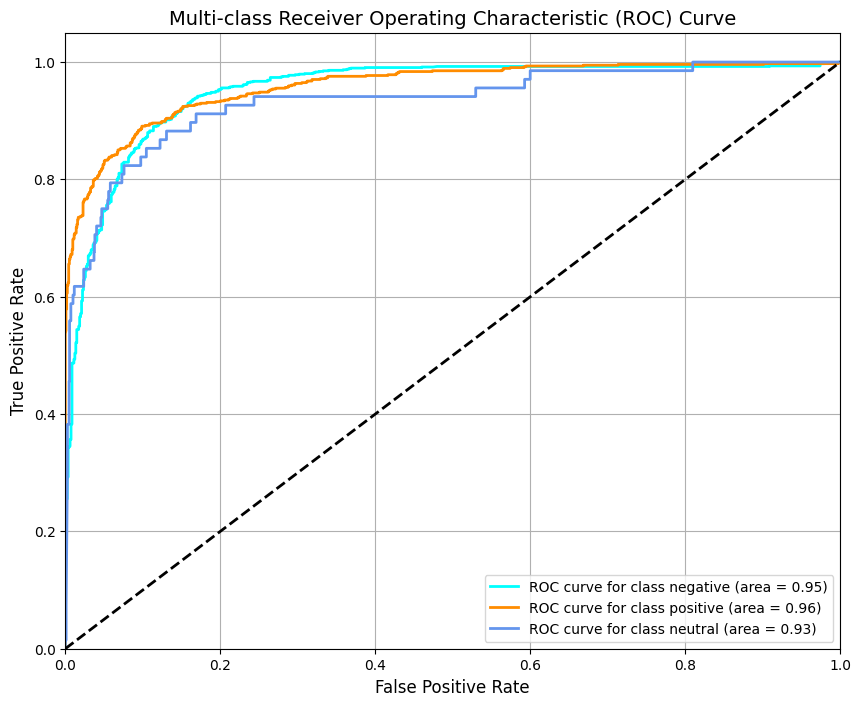

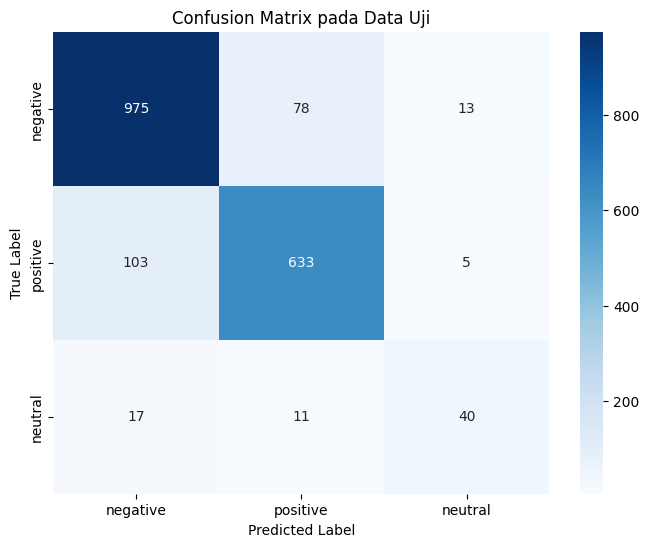

In [ ]:
# @title 8. (Final) Evaluasi Lengkap dengan Tabel Ringkasan dan Grafik ROC

# Impor tambahan yang diperlukan untuk metrik baru dan grafik
from sklearn.metrics import roc_auc_score, matthews_corrcoef, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from itertools import cycle

print("--- Mengevaluasi Model Terbaik pada Data Uji ---")

# Pastikan variabel 'best_run' ada dan berisi data dari Bagian 6 & 7
if 'best_run' in locals() and best_run:

    # Ambil informasi dari run terbaik
    best_model_name = best_run['model']
    final_trainer = best_run['trainer']

    print(f"Melakukan evaluasi final untuk model: {best_model_name}")

    # Muat tokenizer kembali secara manual dari nama model terbaik
    try:
        final_tokenizer = AutoTokenizer.from_pretrained(best_model_name)
    except Exception as e:
        print(f"Gagal memuat tokenizer untuk {best_model_name}. Error: {e}")
        assert False, "Proses berhenti karena tokenizer tidak dapat dimuat."

    def tokenize_for_test(examples):
        return final_tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

    tokenized_test = test_dataset.map(tokenize_for_test, batched=True)

    # Lakukan prediksi pada data uji
    test_predictions = final_trainer.predict(tokenized_test)
    y_pred = np.argmax(test_predictions.predictions, axis=1)
    y_prob = softmax(test_predictions.predictions, axis=1) # Dapatkan probabilitas
    y_true = test_dataset['label']
    n_classes = len(labels)

    # --- Tampilkan Metrik Kinerja Detail ---
    print("\nLaporan Klasifikasi (Classification Report) pada Data Uji:")
    # Meminta output dalam bentuk dictionary untuk digunakan nanti
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0, output_dict=True)
    # Menampilkan laporan dalam bentuk teks yang rapi
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

    # --- BAGIAN BARU: Tabel Ringkasan Metrik Kunci ---
    print("\n" + "="*50)
    print("TABEL RINGKASAN METRIK KINERJA")
    print("="*50)

    mcc_score = matthews_corrcoef(y_true, y_pred)

    lb = LabelBinarizer()
    y_true_binarized = lb.fit_transform(y_true)
    overall_roc_auc = roc_auc_score(y_true_binarized, y_prob, multi_class='ovr')

    summary_data = {
        'Metrik': ['Accuracy', 'F1-Score (Weighted Avg)', 'ROC-AUC (One-vs-Rest)', 'MCC'],
        'Skor': [
            report['accuracy'],
            report['weighted avg']['f1-score'],
            overall_roc_auc,
            mcc_score
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    print("="*50 + "\n")


    # --- BAGIAN BARU: Grafik Multi-Class ROC Curve ---
    fpr = dict()
    tpr = dict()
    roc_auc_per_class = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
        roc_auc_per_class[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve for class {labels[i]} (area = {roc_auc_per_class[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Multi-class Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


    # --- Tampilkan Confusion Matrix (tetap ada) ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix pada Data Uji')
    plt.show()

else:
    print("Error: Variabel 'best_run' tidak ditemukan. Pastikan Bagian 6 dan 7 sudah dijalankan dengan sukses.")